In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Reading the dataset
airline_data= pd.read_csv('/content/Airline_data.csv')

## Quick Analysis of dataset
* Size of the dataset
* Checking the datatype of columns
* Checking the missing values in the dataset

In [ ]:
# Shape of the dataset
airline_data.shape

(103904, 25)

In [ ]:
# datatypes of the columns
airline_data.dtypes

Unnamed: 0                             int64
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure 

* Observed that we have numerical and categorical columns in this dataset.

In [ ]:
# Checking missing values
airline_data.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

* Arrival Delay in Minutes has missing values remaining are all zero missing values.

### Null values imputation
* For the numerical columns we are going to fill with mean or median.
* For categorical columns we are going to fill with mode.

But in our case we have the missing values in numerical column(Arrival delay in minutes).

In [ ]:
# Filling numerical missing column with mean
arival_mean=airline_data['Arrival Delay in Minutes'].mean()
airline_data['Arrival Delay in Minutes']=airline_data['Arrival Delay in Minutes'].fillna(arival_mean)

In [ ]:
# After filling the null values checking whether it is filled or not
airline_data.isnull().sum().sum()

0

### Removing unwanted columns
* Unwanted_0 and id columns are the unnecessary columns these are not useful for model building so we have to drop these kind of features from the dataset.

In [ ]:
# Dropping the unnecessary columns
airline_data=airline_data.drop(['Unnamed: 0','id'],axis=1)

### Separating the Numerical and categorical columns

In [ ]:
# Get names of numerical columns
numerical_cols = airline_data.select_dtypes(include=[np.number]).columns

# Get names of categorical columns
categorical_cols = airline_data.select_dtypes(include=['object']).columns

print(len(numerical_cols))
print(len(categorical_cols))

18
5


# Explorative Data Analysis (EDA)
* Heatmap correlation between numerical columns
* Frequency plots for categorical columns
* Box plots for numerical columns
* Histogram plots for numerical columns
* Bi-variate analysis

<ipython-input-10-3075cf67bb64>:6: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = airline_data.corr()


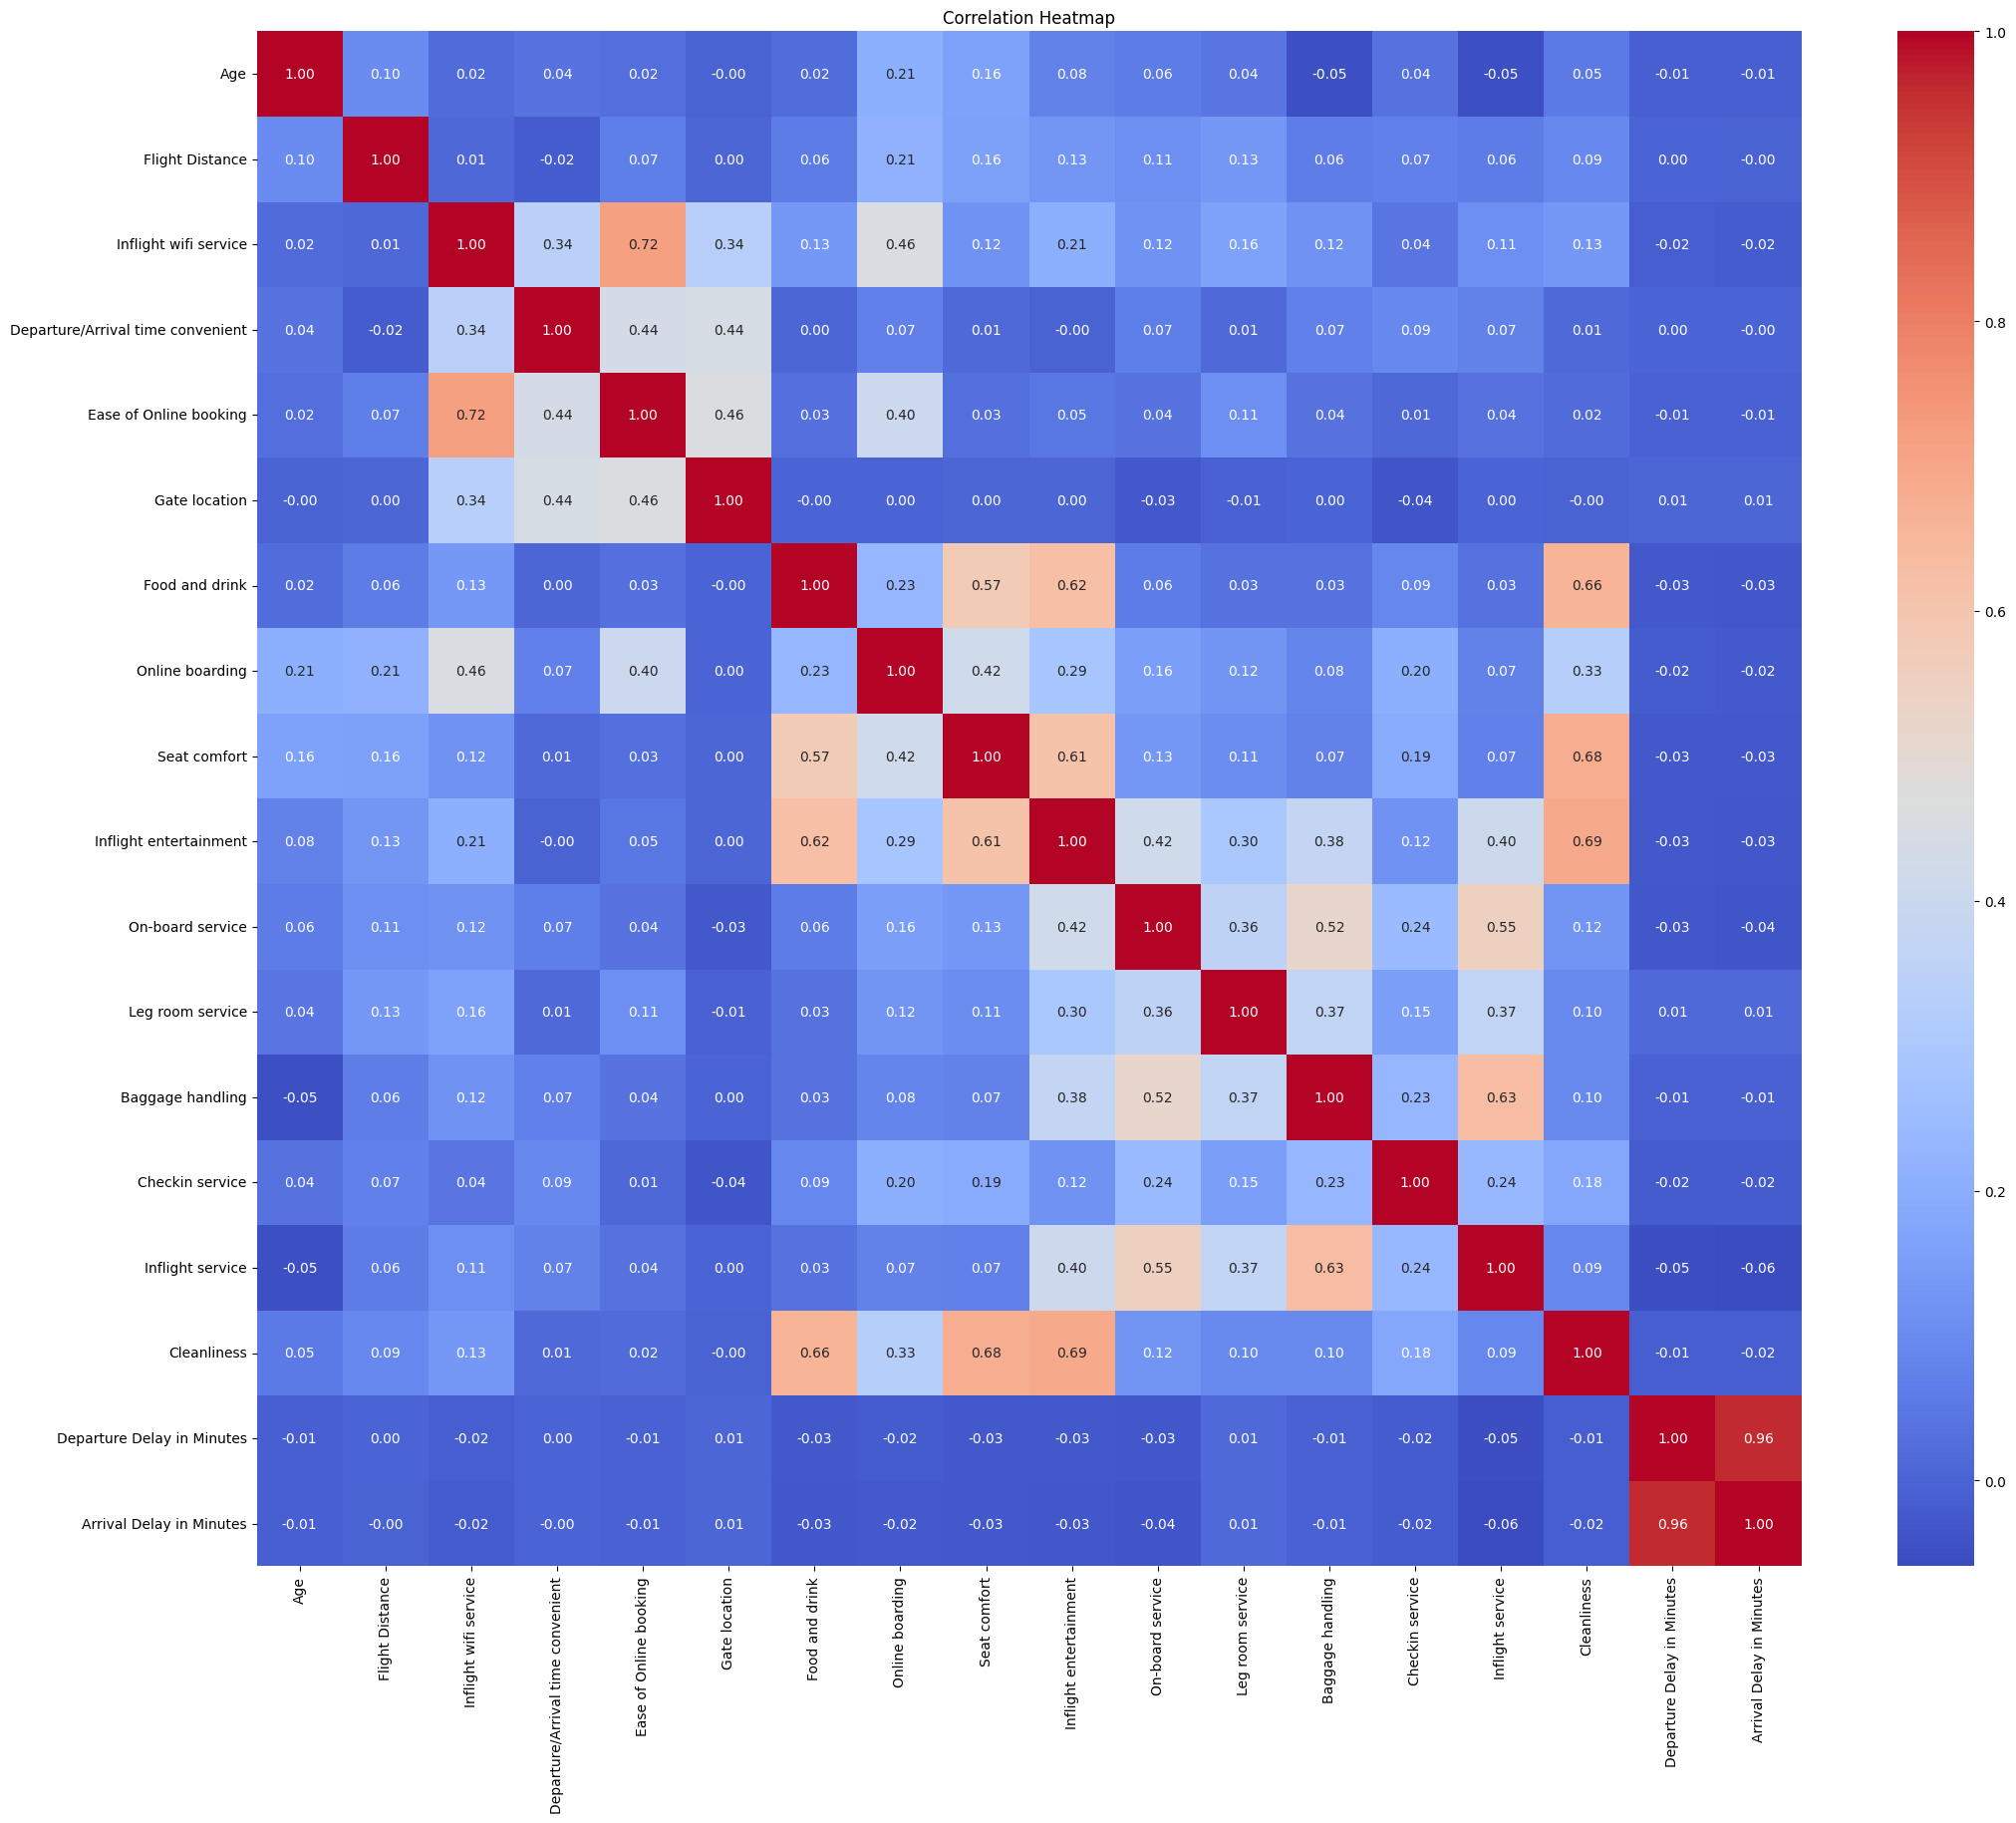

In [ ]:
# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for all columns in  DataFrame
correlation_matrix = airline_data.corr()

# Create a heatmap
plt.figure(figsize=(25, 20))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

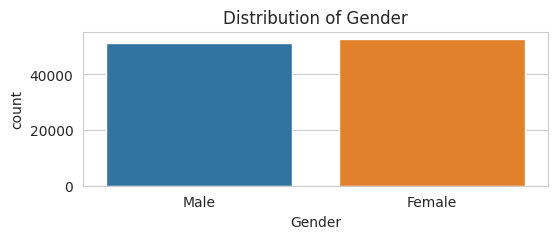

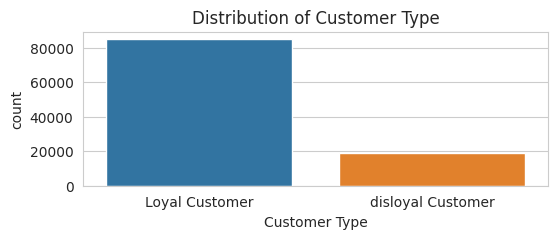

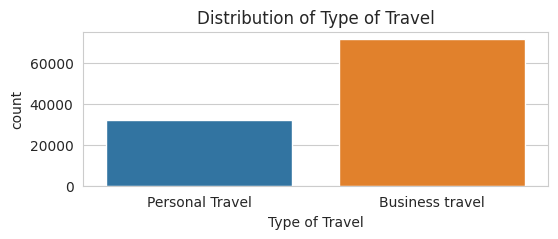

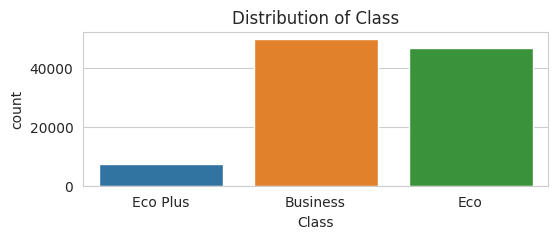

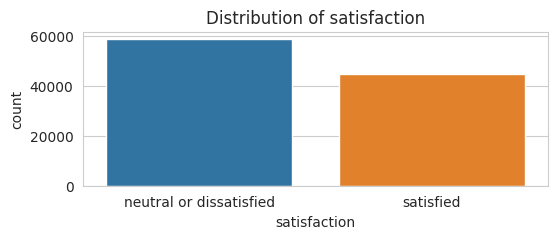

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Iterate through the list of categorical columns
for col in categorical_cols:
    # Create a new figure for each column
    plt.figure(figsize=(6, 2))

    # Create a countplot
    sns.countplot(x=col, data=airline_data)

    # Set the title of the plot
    plt.title(f'Distribution of {col}')

    # Show the plot
    plt.show()


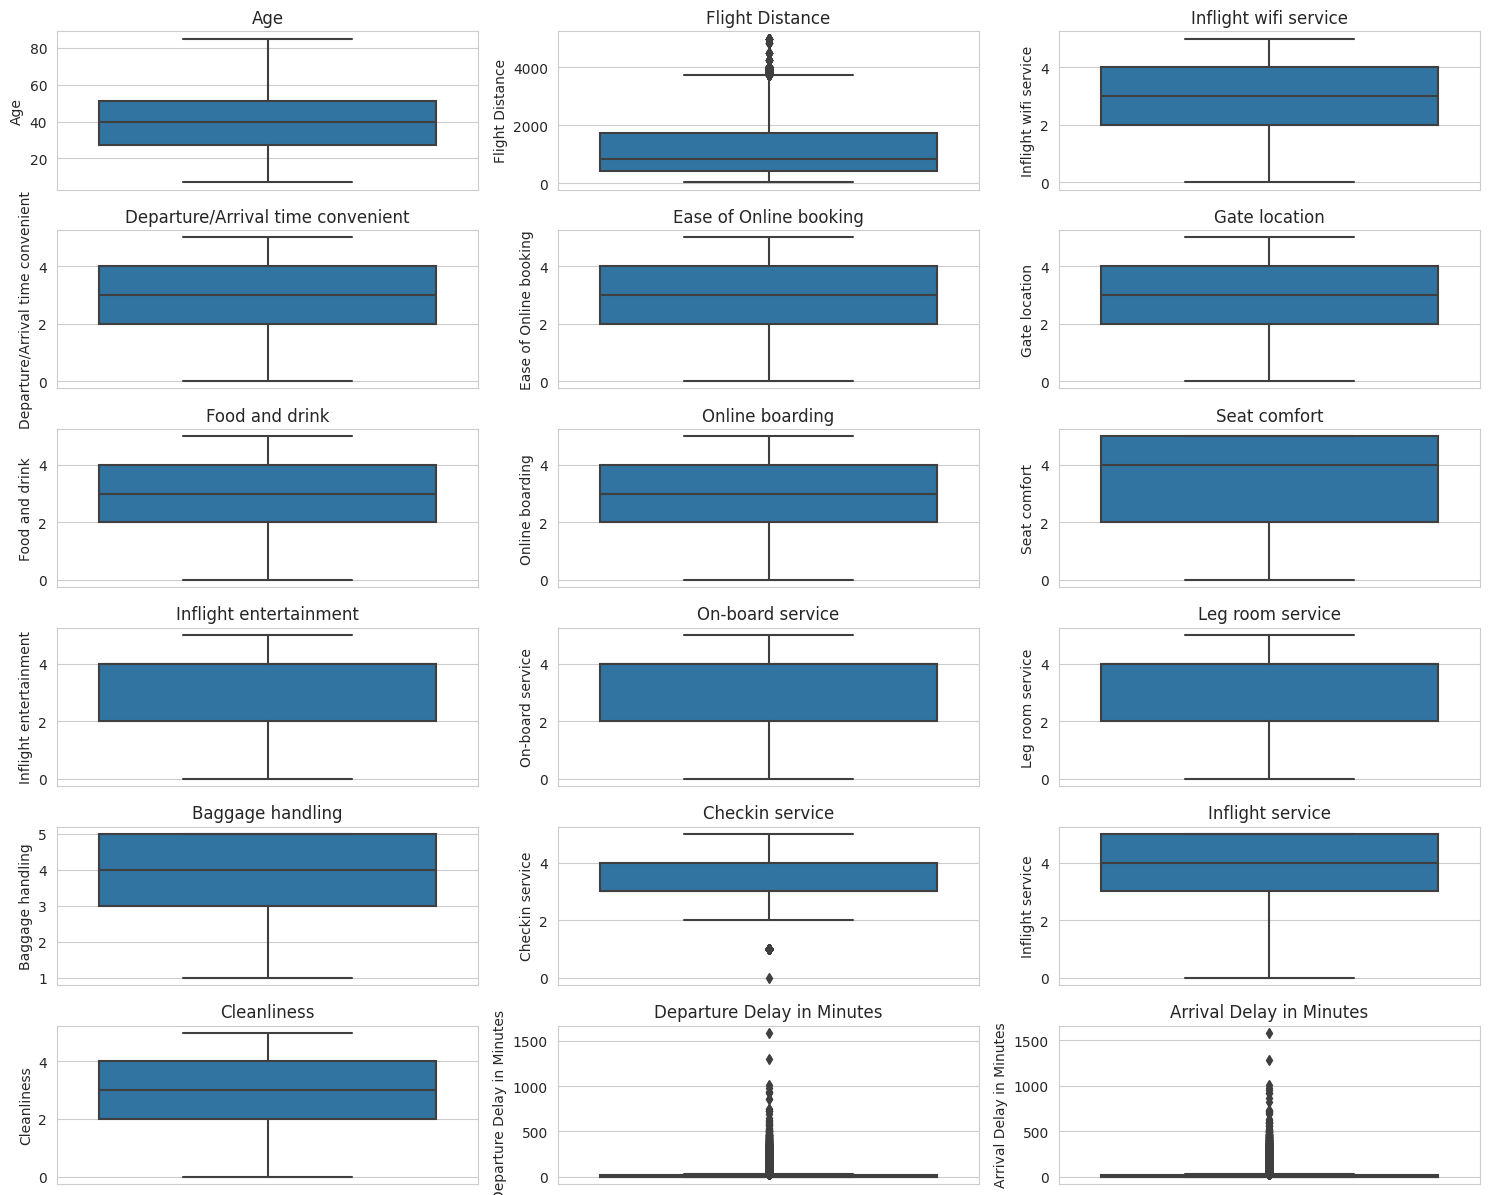

In [ ]:
# showing the boxplots for each column
plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(10, 3, i)
    sns.boxplot(y=airline_data[col])
    plt.title(col)
    plt.xlabel('')

plt.tight_layout()
plt.show()

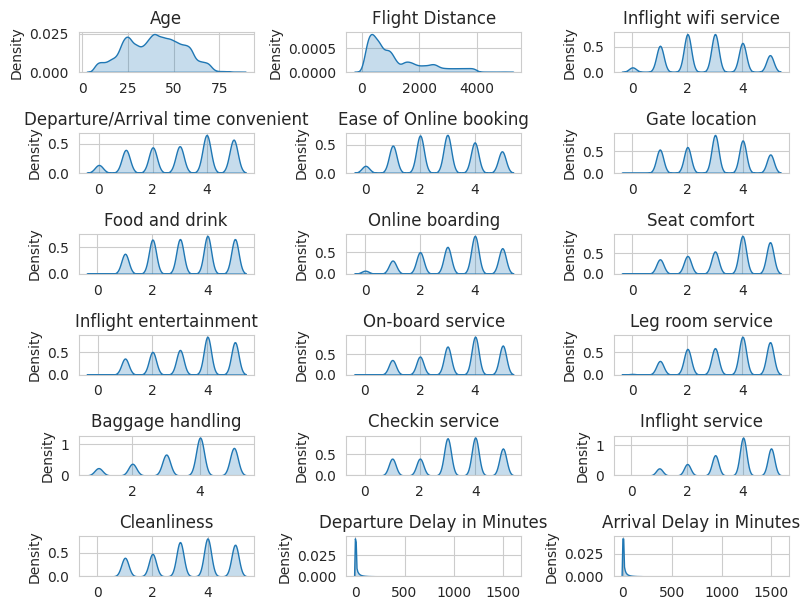

In [ ]:
# Set up the matplotlib figure
plt.figure(figsize=(8, 10))

# Create a density plot for each column
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(10, 3, i)
    sns.kdeplot(airline_data[col], fill=True)
    plt.title(col)
    plt.xlabel('')

plt.tight_layout()
plt.show()

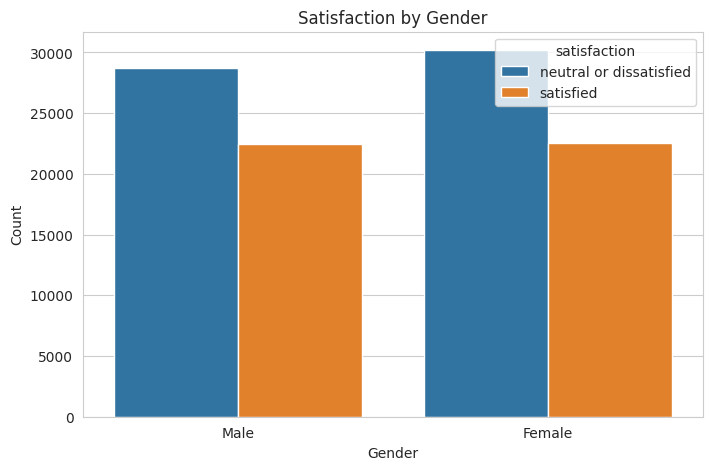

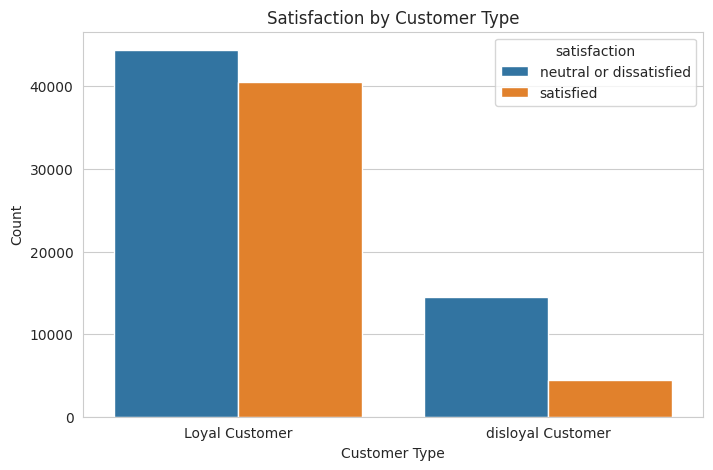

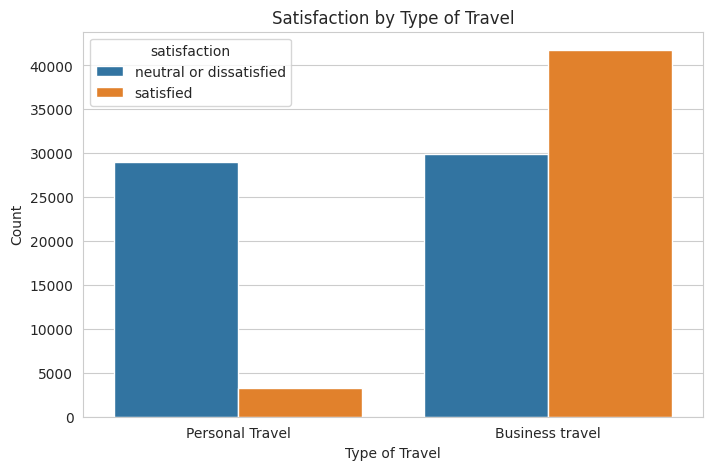

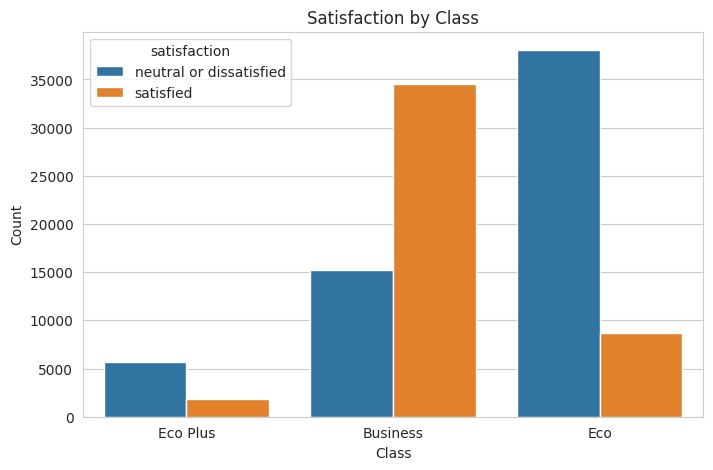

In [ ]:
# Bivariate analysis
columns_to_analyze = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a bar plot for each categorical variable against satisfaction
for col in columns_to_analyze:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue='satisfaction', data=airline_data)
    plt.title(f'Satisfaction by {col}')
    plt.ylabel('Count')
    plt.show()

# Data Transformation
* Converting categorical data to numerical data using lable encoder method.

* Normalizing the numerical data which are having outliers to make the data distribution normal.

In [ ]:
# Converting categorical data to numerical data
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply LabelEncoder to each categorical column
for col in categorical_cols:
    airline_data[col] = le.fit_transform(airline_data[col])


In [ ]:
# Checking whether all features having numerical datatype
airline_data.dtypes

Gender                                 int64
Customer Type                          int64
Age                                    int64
Type of Travel                         int64
Class                                  int64
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
satisfacti

In [ ]:
# Normalizing the numerical features
norma_cols=['Age','Flight Distance','Departure Delay in Minutes','Arrival Delay in Minutes']
from sklearn.preprocessing import StandardScaler
# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the specified columns
airline_data[norma_cols] = scaler.fit_transform(airline_data[norma_cols])


# Data Preparation
* Dividing the X(independent) and Y(dependent) variable.
* Splitting data into Train and Test split

In [ ]:
# Independent variables into X dataframe
X=airline_data.drop('satisfaction',axis=1)
# Dependent (Target) variable into y dataframe
y=airline_data['satisfaction']

In [ ]:
# Splitting data into Train and Test split
from sklearn.model_selection import train_test_split

# Splitting the data into train and test sets using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Data Modelling
* Training using machine learning algorithms
* Testing model performance using test data

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Instantiate the models
logreg = LogisticRegression()
decision_tree = DecisionTreeClassifier()
random_forest = RandomForestClassifier()
xgboost = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
adaboost = AdaBoostClassifier()

# List of models
models = [logreg, decision_tree, random_forest, xgboost, adaboost]

# Training and evaluation of each model
for model in models:
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Print model name and classification report
    print(model.__class__.__name__)
    print(classification_report(y_test, y_pred))
    print('-' * 60)


LogisticRegression
              precision    recall  f1-score   support

           0       0.88      0.91      0.89     14720
           1       0.87      0.84      0.85     11256

    accuracy                           0.88     25976
   macro avg       0.88      0.87      0.87     25976
weighted avg       0.88      0.88      0.88     25976

------------------------------------------------------------
DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     14720
           1       0.93      0.94      0.94     11256

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976

------------------------------------------------------------
RandomForestClassifier
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14720
           1       0.97      0.94      0.95     11

# Hyperparameter Tuning
* GridsearchCv:

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100,150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'colsample_bytree': [0.5, 0.7, 1],
    'subsample': [0.6, 0.8, 1]
}

# Initialize the XGBoost Classifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, verbose=2, n_jobs=-1)

# Fit GridSearchCV to the data
grid_search.fit(X_train, y_train)

# Review the best parameters and performance
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)


Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.6}
Best Score: 0.9607586490093419


# Crossvalidation
* This method is used to prevent overfitting

In [ ]:
from sklearn.model_selection import cross_val_score

# Initialize the XGBoost Classifier with desired hyperparameters
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', **best_params)

# Perform cross-validation
scores = cross_val_score(xgb, X, y, cv=5)  # 5-fold cross-validation

# Print the results
print("Cross-Validation Accuracy Scores:", scores)
print("Mean CV Accuracy:", np.mean(scores))
print("Standard Deviation in CV Scores:", np.std(scores))

Cross-Validation Accuracy Scores: [0.96010779 0.96203263 0.95996343 0.96285068 0.96357074]
Mean CV Accuracy: 0.9617050533731881
Standard Deviation in CV Scores: 0.0014481065734109838


# Predictive power of features
* Using feature importance method to get the weights of each feature for predicting the target variable.

* Based on the weights we can tell most important features to detect y variable.

In [ ]:
#Fitting the XGB model on whole data
xgb.fit(X,y)
# Extract feature importances
feature_importances = xgb.feature_importances_

# Create a DataFrame to hold the feature names and their importance scores
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'weight': feature_importances
})

# Sort the DataFrame based on the weights in descending order for better visualization
feature_importance_df = feature_importance_df.sort_values(by='weight', ascending=False)

# Display the DataFrame
print(feature_importance_df)

                              feature    weight
11                    Online boarding  0.390971
3                      Type of Travel  0.118774
6               Inflight wifi service  0.078504
4                               Class  0.051941
17                    Checkin service  0.046312
1                       Customer Type  0.045978
13             Inflight entertainment  0.041166
14                   On-board service  0.037706
15                   Leg room service  0.031399
16                   Baggage handling  0.026848
12                       Seat comfort  0.026497
9                       Gate location  0.020944
19                        Cleanliness  0.020406
18                   Inflight service  0.018274
2                                 Age  0.008792
21           Arrival Delay in Minutes  0.008610
7   Departure/Arrival time convenient  0.008189
8              Ease of Online booking  0.007586
5                     Flight Distance  0.003399
0                              Gender  0

**Top Influential Features:**

The most influential feature in our model is Online boarding, with a weight of approximately 0.391. This suggests that the online boarding process has the most significant impact on our target variable (likely customer satisfaction or a similar metric).
The second most important feature is Type of Travel, followed by Inflight wifi service, indicating that these aspects are also crucial in determining the outcome.

# Predicting on new data with the Best model

* Selected XGBClassifier to predict on new data based on performance.

* Giving some values to features based on assumption.

In [ ]:
import pandas as pd

# Assumed values for each feature
assumed_values = {
    'Gender': 1,  #  1 for male, 0 for female
    'Customer Type': 0,  #  0 for loyal customer, 1 for disloyal
    'Age': 35,  # A middle-aged passenger
    'Type of Travel': 1,  #  1 for Business travel, 0 for Personal Travel
    'Class': 2,  #  0 for Economy, 1 for Business, 2 for First Class
    'Flight Distance': 1200,  # Medium distance flight in miles
    'Inflight wifi service': 4,  # Good wifi service
    'Departure/Arrival time convenient': 3,  # Moderately convenient
    'Ease of Online booking': 4,  # Good online booking experience
    'Gate location': 3,  # Moderately convenient gate location
    'Food and drink': 3,  # Average food and drink
    'Online boarding': 4,  # Good online boarding experience
    'Seat comfort': 4,  # Comfortable seats
    'Inflight entertainment': 4,  # Good inflight entertainment
    'On-board service': 4,  # Good on-board service
    'Leg room service': 3,  # Average leg room
    'Baggage handling': 4,  # Good baggage handling
    'Checkin service': 3,  # Good check-in service
    'Inflight service': 4,  # Good inflight service
    'Cleanliness': 4,  # High cleanliness
    'Departure Delay in Minutes': 10,  # Slight delay
    'Arrival Delay in Minutes': 5  # Minimal delay
}

# Create a DataFrame for the assumed sample
assumed_sample = pd.DataFrame([assumed_values])

# Making a prediction using the XGBoost model
prediction = xgb.predict(assumed_sample)

# Output the prediction
print(f"Predicted outcome for the assumed sample: {prediction[0]}")


Predicted outcome for the assumed sample: 0


* Model is predicted as 0 means passenger dissatisfied. 1 means satisfied.